# 01 — Exploratory Data Analysis


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from scipy import stats

In [52]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
# Set display options and plot aesthetics
pd.set_option('display.max_columns', 50)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Define paths for raw data and plots
RAW = Path('../data/raw')
PLOTS = Path('../outputs/plots')
PLOTS.mkdir(parents=True, exist_ok=True)



# Load datasets
genres_v2    = pd.read_csv(RAW / 'dataset_of_songs/genres_v2.csv', low_memory=False)
spotify_2023 = pd.read_csv(RAW / 'spotify_2023/spotify_data_12_20_2023.csv', low_memory=False)
audio_apr    = pd.read_csv(RAW / 'spotify_audio_features/SpotifyAudioFeaturesApril2019.csv')
audio_nov    = pd.read_csv(RAW / 'spotify_audio_features/SpotifyAudioFeaturesNov2018.csv')
sp_tracks    = pd.read_csv(RAW / 'spotify_tracks/dataset.csv', low_memory=False)
ultimate     = pd.read_csv(RAW / 'ultimate_spotify_tracks/SpotifyFeatures.csv')

datasets = {
    'genres_v2'              : genres_v2,
    'spotify_data_2023'      : spotify_2023,
    'audio_features_apr2019' : audio_apr,
    'audio_features_nov2018' : audio_nov,
    'spotify_tracks'         : sp_tracks,
    'ultimate_spotify_tracks': ultimate,
}

for name, df in datasets.items():
    print(f'{"="*60}')
    print(f'  {name}')
    print(f'  Shape : {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'  Columns: {list(df.columns)}')
    print(f'{"="*60}')
    display(df.head())
    print()

  genres_v2
  Shape : 42,305 rows x 22 cols
  Columns: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'type', 'id', 'uri', 'track_href', 'analysis_url', 'duration_ms', 'time_signature', 'genre', 'song_name', 'Unnamed: 0', 'title']


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature,genre,song_name,Unnamed: 0,title
0,0.831,0.814,2,-7.364,1,0.4200,0.0598,0.013400,0.0556,0.3890,156.985,audio_features,2Vc6NJ9PW9gD9q343XFRKx,spotify:track:2Vc6NJ9PW9gD9q343XFRKx,https://api.spotify.com/v1/tracks/2Vc6NJ9PW9gD...,https://api.spotify.com/v1/audio-analysis/2Vc6...,124539,4,Dark Trap,Mercury: Retrograde,NaN,NaN
1,0.719,0.493,8,-7.230,1,0.0794,0.4010,0.000000,0.1180,0.1240,115.080,audio_features,7pgJBLVz5VmnL7uGHmRj6p,spotify:track:7pgJBLVz5VmnL7uGHmRj6p,https://api.spotify.com/v1/tracks/7pgJBLVz5Vmn...,https://api.spotify.com/v1/audio-analysis/7pgJ...,224427,4,Dark Trap,Pathology,NaN,NaN
2,0.850,0.893,5,-4.783,1,0.0623,0.0138,0.000004,0.3720,0.0391,218.050,audio_features,0vSWgAlfpye0WCGeNmuNhy,spotify:track:0vSWgAlfpye0WCGeNmuNhy,https://api.spotify.com/v1/tracks/0vSWgAlfpye0...,https://api.spotify.com/v1/audio-analysis/0vSW...,98821,4,Dark Trap,Symbiote,NaN,NaN
3,0.476,0.781,0,-4.710,1,0.1030,0.0237,0.000000,0.1140,0.1750,186.948,audio_features,0VSXnJqQkwuH2ei1nOQ1nu,spotify:track:0VSXnJqQkwuH2ei1nOQ1nu,https://api.spotify.com/v1/tracks/0VSXnJqQkwuH...,https://api.spotify.com/v1/audio-analysis/0VSX...,123661,3,Dark Trap,ProductOfDrugs (Prod. The Virus and Antidote),NaN,NaN
4,0.798,0.624,2,-7.668,1,0.2930,0.2170,0.000000,0.1660,0.5910,147.988,audio_features,4jCeguq9rMTlbMmPHuO7S3,spotify:track:4jCeguq9rMTlbMmPHuO7S3,https://api.spotify.com/v1/tracks/4jCeguq9rMTl...,https://api.spotify.com/v1/audio-analysis/4jCe...,123298,4,Dark Trap,Venom,NaN,NaN



  spotify_data_2023
  Shape : 375,141 rows x 49 cols
  Columns: ['album_id', 'album_name', 'album_popularity', 'album_type', 'artists', 'artist_0', 'artist_1', 'artist_2', 'artist_3', 'artist_4', 'artist_id', 'duration_sec', 'label', 'release_date', 'total_tracks', 'track_id', 'track_name', 'track_number', 'artist_genres', 'artist_popularity', 'followers', 'name', 'genre_0', 'genre_1', 'genre_2', 'genre_3', 'genre_4', 'acousticness', 'analysis_url', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'track_href', 'type', 'uri', 'valence', 'explicit', 'track_popularity', 'release_year', 'release_month', 'rn']


,album_id,album_name,album_popularity,album_type,artists,artist_0,artist_1,artist_2,artist_3,artist_4,artist_id,duration_sec,label,release_date,total_tracks,track_id,track_name,track_number,artist_genres,artist_popularity,followers,name,genre_0,genre_1,genre_2,genre_3,genre_4,acousticness,analysis_url,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,track_href,type,uri,valence,explicit,track_popularity,release_year,release_month,rn
0,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,['AB'],AB,NaN,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,92.063,About Benjamin Records,2023-04-15 00:00:00 UTC,8,5JucnTkqh8uCZGggL1xxvv,Intro,1,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.03050,https://api.spotify.com/v1/audio-analysis/5Juc...,0.622,92064.0,0.554,0.000001,5.0,0.3920,-9.505,0.0,0.414,72.546,4.0,https://api.spotify.com/v1/tracks/5JucnTkqh8uC...,audio_features,spotify:track:5JucnTkqh8uCZGggL1xxvv,0.382,True,0.0,2023.0,April,1
1,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,"['AB', '22nd Jim']",AB,22nd Jim,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,125.320,About Benjamin Records,2023-04-15 00:00:00 UTC,8,4VWrKNG3ssyZeboTgQ7Kj1,Play It Cool,5,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.01120,https://api.spotify.com/v1/audio-analysis/4VWr...,0.899,125320.0,0.701,0.000000,11.0,0.1530,-6.182,0.0,0.138,101.581,4.0,https://api.spotify.com/v1/tracks/4VWrKNG3ssyZ...,audio_features,spotify:track:4VWrKNG3ssyZeboTgQ7Kj1,0.193,True,1.0,2023.0,April,1
2,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,"['AB', 'Veeze']",AB,Veeze,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,139.800,About Benjamin Records,2023-04-15 00:00:00 UTC,8,6JsVrTLJPSOSpgJSnZyfSK,3 Peat,3,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.08150,https://api.spotify.com/v1/audio-analysis/6JsV...,0.782,139800.0,0.716,0.000000,10.0,0.1260,-8.295,0.0,0.382,99.789,4.0,https://api.spotify.com/v1/tracks/6JsVrTLJPSOS...,audio_features,spotify:track:6JsVrTLJPSOSpgJSnZyfSK,0.835,True,1.0,2023.0,April,1
3,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,['AB'],AB,NaN,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,147.777,About Benjamin Records,2023-04-15 00:00:00 UTC,8,7pZpw1xJWIavCUGqXPPriP,Affiliated,6,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.00413,https://api.spotify.com/v1/audio-analysis/7pZp...,0.944,147778.0,0.582,0.000000,1.0,0.0961,-9.205,1.0,0.297,105.010,4.0,https://api.spotify.com/v1/tracks/7pZpw1xJWIav...,audio_features,spotify:track:7pZpw1xJWIavCUGqXPPriP,0.252,True,0.0,2023.0,April,1
4,4zH8bbEjLe0Gdbv2FVLjnK,Son Of Tabu,1,album,['AB'],AB,NaN,NaN,NaN,NaN,08jcfs5JspUBqM3rbFNUzm,102.600,About Benjamin Records,2023-04-15 00:00:00 UTC,8,0ylqwc3gcJdJotKd4SfMiu,Springfield,8,[],0,133,AB,NaN,NaN,NaN,NaN,NaN,0.01290,https://api.spotify.com/v1/audio-analysis/0ylq...,0.527,102600.0,0.641,0.000000,5.0,0.0869,-11.173,0.0,0.730,172.723,4.0,https://api.spotify.com/v1/tracks/0ylqwc3gcJdJ...,audio_features,spotify:track:0ylqwc3gcJdJotKd4SfMiu,0.380,True,0.0,2023.0,April,1



  audio_features_apr2019
  Shape : 130,663 rows x 17 cols
  Columns: ['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'popularity']


...

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118,44
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371,10
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382,63
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641,9
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928,8



  spotify_tracks
  Shape : 114,000 rows x 21 cols
  Columns: ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic



  ultimate_spotify_tracks
  Shape : 232,725 rows x 18 cols
  Columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [53]:
# Audio features common across all datasets
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]

In [54]:
# Check data types of each dataset
for name, df in datasets.items():
    print(f'\n=== {name} ===')
    print(df.dtypes.to_string())


=== genres_v2 ===
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
type                    str
id                      str
uri                     str
track_href              str
analysis_url            str
duration_ms           int64
time_signature        int64
genre                   str
song_name               str
Unnamed: 0          float64
title                   str

=== spotify_data_2023 ===
album_id                 str
album_name               str
album_popularity       int64
album_type               str
artists                  str
artist_0                 str
artist_1                 str
artist_2                 str
artist_3                 str
artist_4                 str
artist_id                str
duration_sec       

## 3. Missing Values


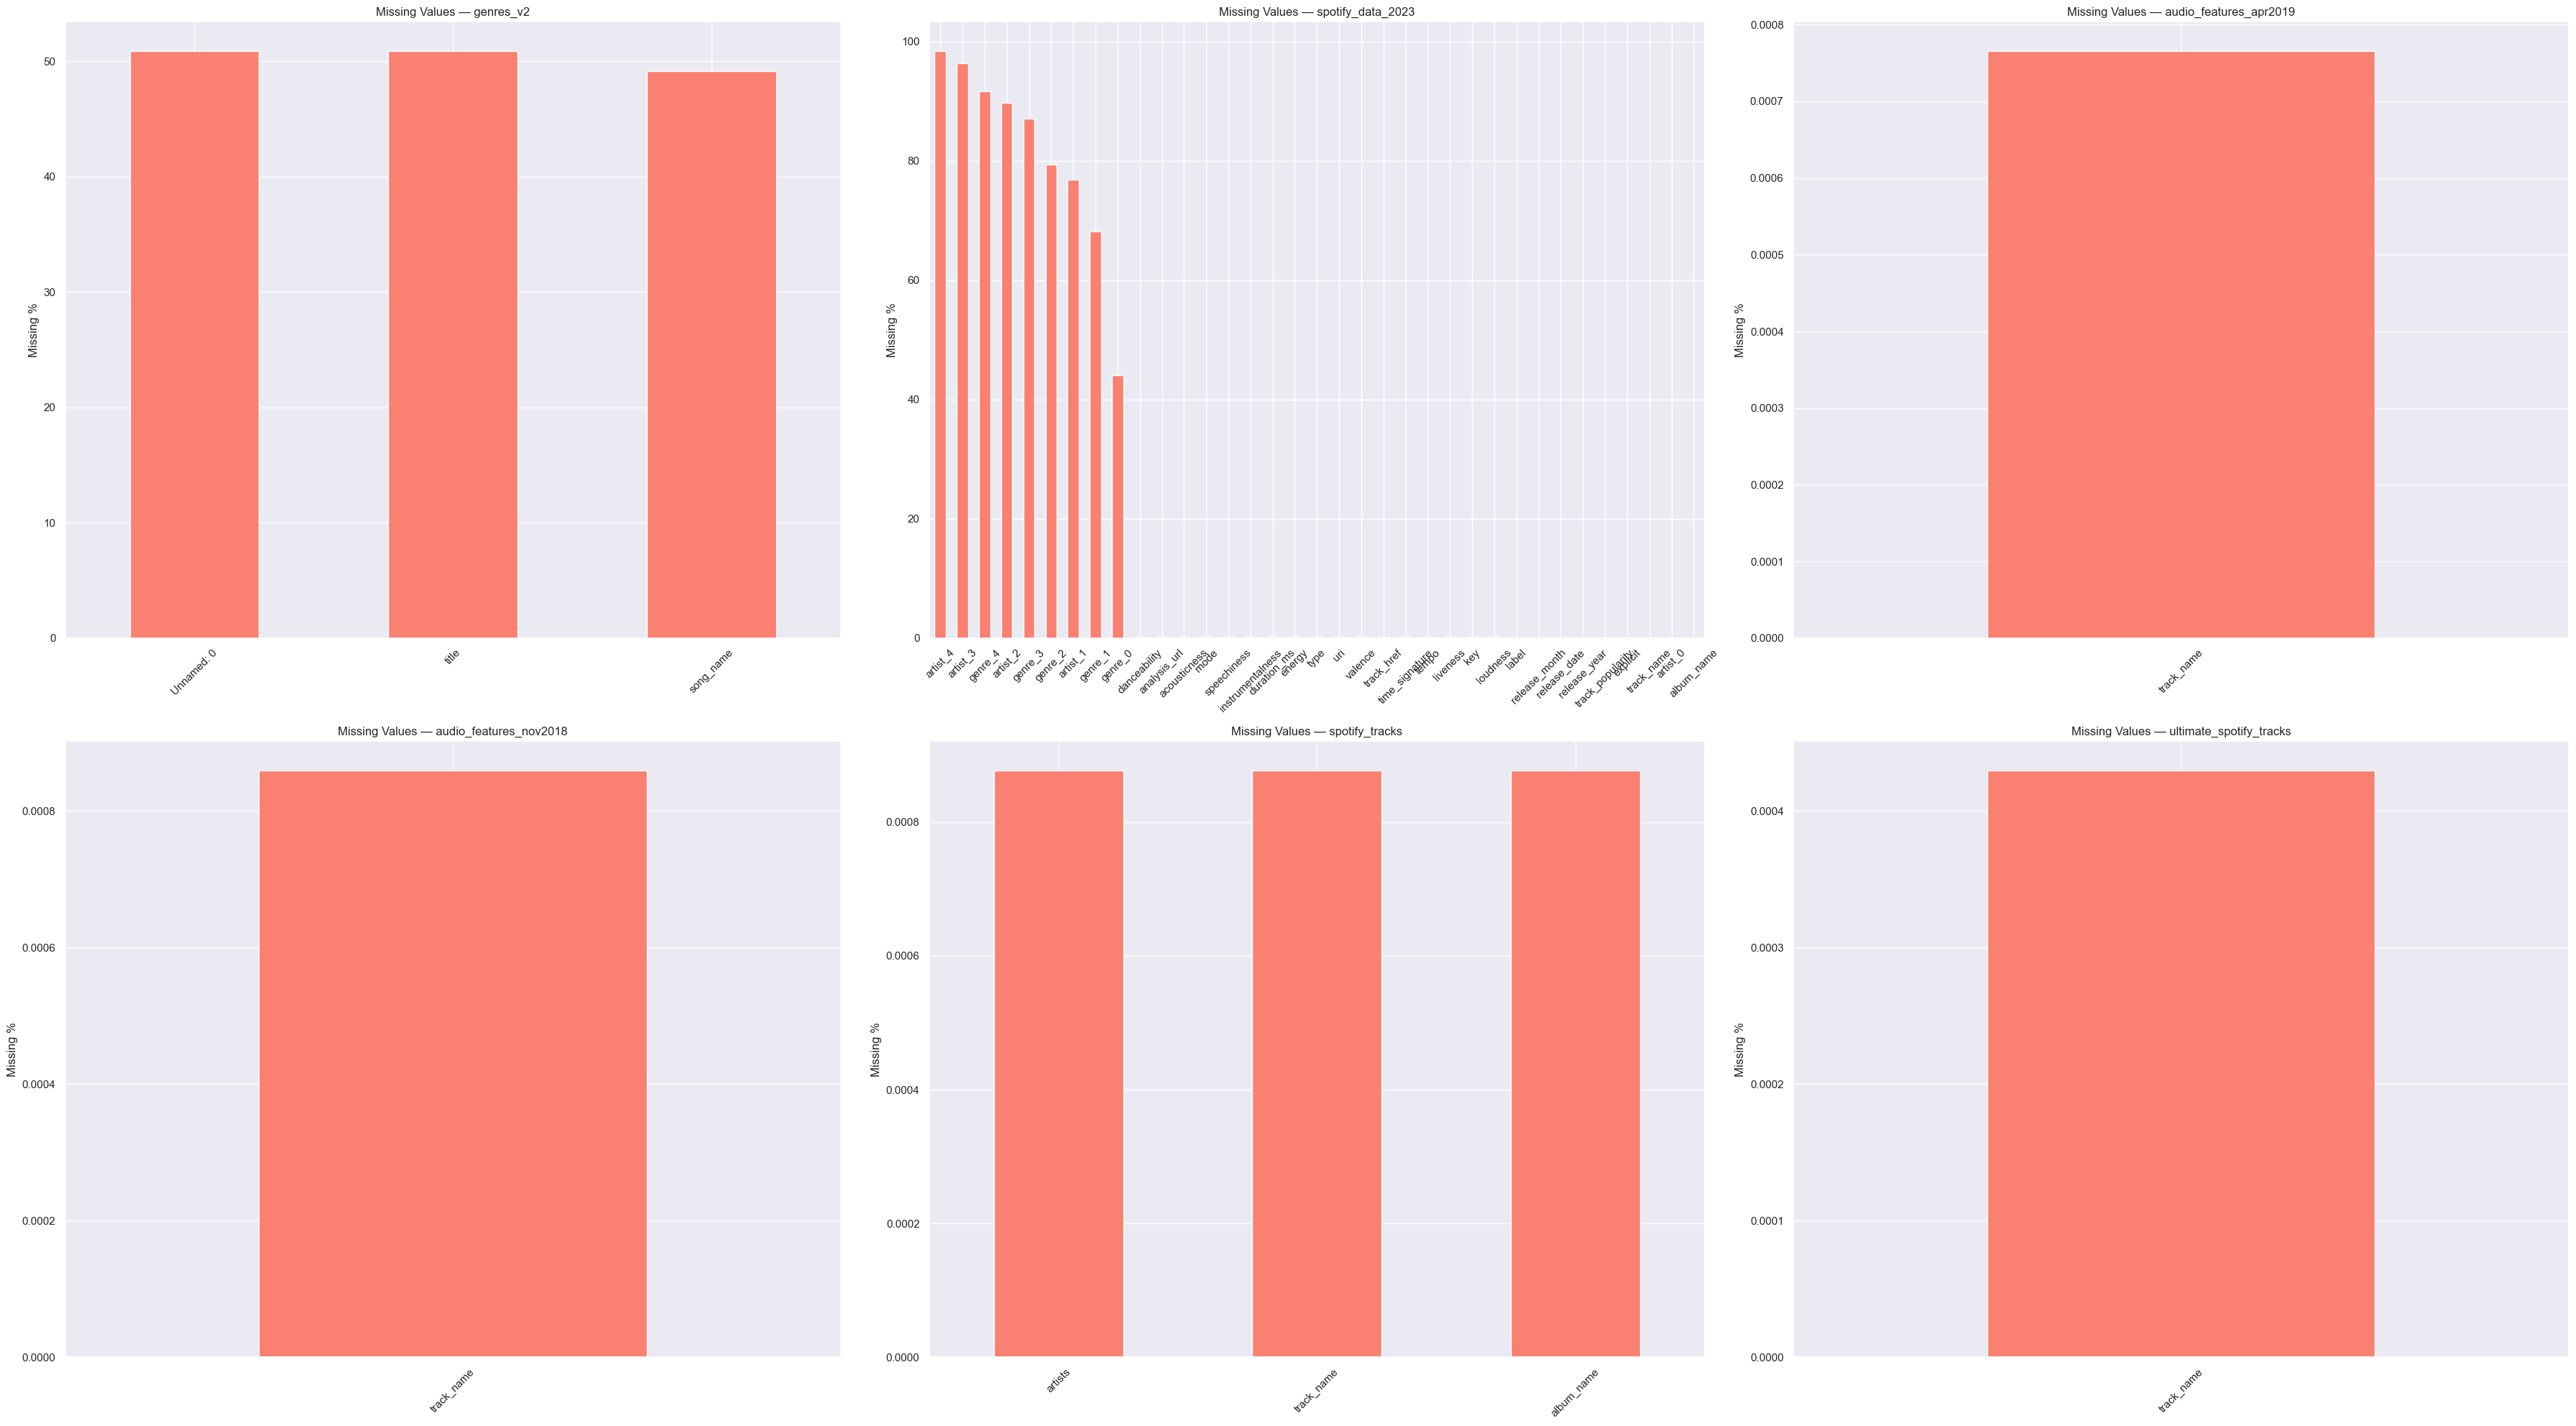

  genres_v2
  Column                                Missing Count  Missing %
  ------------------------------------------------------------
  Unnamed: 0                                   21,525     50.88%
  title                                        21,525     50.88%
  song_name                                    20,786     49.13%

  spotify_data_2023
  Column                                Missing Count  Missing %
  ------------------------------------------------------------
  artist_4                                    369,054     98.38%
  artist_3                                    361,318     96.32%
  genre_4                                     343,824     91.65%
  artist_2                                    336,841     89.79%
  genre_3                                     326,531     87.04%
  genre_2                                     297,922     79.42%
  artist_1                                    288,062     76.79%
  genre_1                                     255,655     68.

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    if missing.empty:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=12)
    else:
        missing.plot(kind='bar', ax=ax, color='salmon')
        ax.set_ylabel('Missing %')
    ax.set_title(f'Missing Values — {name}')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(PLOTS / 'missing_values.png', dpi=150)
plt.show()

# Detailed missing value report for each dataset
for name, df in datasets.items():
    print(f'{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    
    missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    missing = missing[missing > 0]
    
    if missing.empty:
        print('  No missing values')
    else:
        print(f'  {"Column":<35} {"Missing Count":>15} {"Missing %":>10}')
        print(f'  {"-"*60}')
        for col, pct in missing.items():
            count = df[col].isnull().sum()
            print(f'  {col:<35} {count:>15,} {pct:>9.2f}%')
    print()

In [56]:
#check for duplicates in each dataset
print('Duplicate rows:')
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    print(f'  {name:20s}: {dupes:>6,} duplicates ({dupes/len(df)*100:.2f}%)')

Duplicate rows:
  genres_v2           :      0 duplicates (0.00%)
  spotify_data_2023   :      0 duplicates (0.00%)
  audio_features_apr2019:      0 duplicates (0.00%)
  audio_features_nov2018:      0 duplicates (0.00%)
  spotify_tracks      :      0 duplicates (0.00%)
  ultimate_spotify_tracks:      0 duplicates (0.00%)


  Audio Feature Statistics (sp_tracks)
  Feature                  Mean     Mode   Median      Std      Min      Max
  -----------------------------------------------------------------
  danceability            0.567    0.647    0.580    0.174    0.000    0.985
  energy                  0.641    0.876    0.685    0.252    0.000    1.000
  loudness               -8.259   -5.662   -7.004    5.029  -49.531    4.532
  speechiness             0.085    0.032    0.049    0.106    0.000    0.965
  acousticness            0.315    0.995    0.169    0.333    0.000    0.996
  instrumentalness        0.156    0.000    0.000    0.310    0.000    1.000
  liveness                0.214    0.108    0.132    0.190    0.000    1.000
  valence                 0.474    0.961    0.464    0.259    0.000    0.995
  tempo                 122.148    0.000  122.017   29.978    0.000  243.372


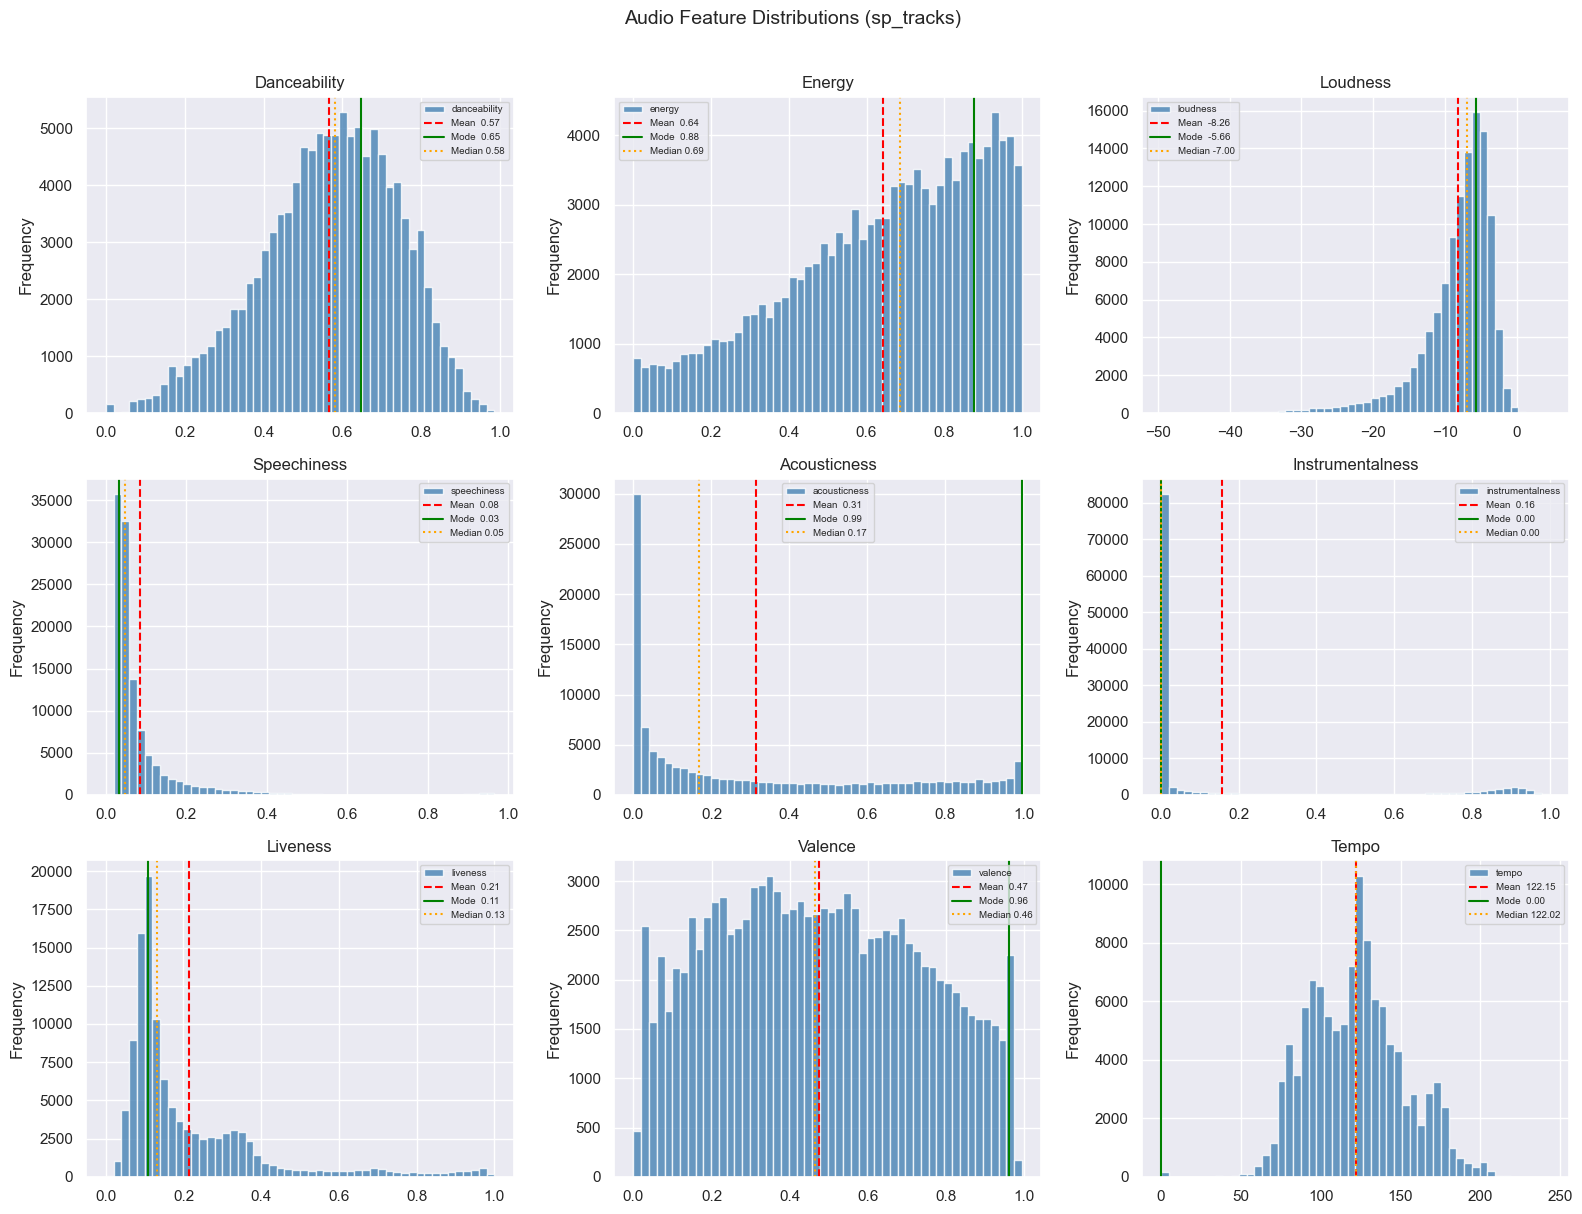

In [ ]:
# Analyze distributions of audio features in sp_tracks dataset

df = sp_tracks.copy()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

print(f'{"="*65}')
print(f'  Audio Feature Statistics (sp_tracks)')
print(f'{"="*65}')
print(f'  {"Feature":<20} {"Mean":>8} {"Mode":>8} {"Median":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print(f'  {"-"*65}')

for ax, feature in zip(axes, AUDIO_FEATURES):
    if feature in df.columns:
        data = df[feature].dropna()
        mean   = data.mean()
        mode   = data.mode()[0]
        median = data.median()
        std    = data.std()
        mn     = data.min()
        mx     = data.max()

        # Plot histogram
        data.plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='white', alpha=0.8)

        # Mean line
        ax.axvline(mean,   color='red',    linestyle='--', linewidth=1.5, label=f'Mean  {mean:.2f}')
        # Mode line
        ax.axvline(mode,   color='green',  linestyle='-',  linewidth=1.5, label=f'Mode  {mode:.2f}')
        # Median line
        ax.axvline(median, color='orange', linestyle=':',  linewidth=1.5, label=f'Median {median:.2f}')

        ax.set_title(feature.capitalize())
        ax.set_xlabel('')
        ax.legend(fontsize=7)

        # Print stats
        print(f'  {feature:<20} {mean:>8.3f} {mode:>8.3f} {median:>8.3f} {std:>8.3f} {mn:>8.3f} {mx:>8.3f}')

print(f'{"="*65}')

plt.suptitle('Audio Feature Distributions (sp_tracks)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS / 'feature_distributions.png', dpi=150)
plt.show()

## 6. Feature Statistics Summary


In [58]:
available_features = [f for f in AUDIO_FEATURES if f in sp_tracks.columns]
sp_tracks[available_features].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,0.567,0.641,-8.259,0.085,0.315,0.156,0.214,0.474,122.148
std,0.174,0.252,5.029,0.106,0.333,0.310,0.190,0.259,29.978
min,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.456,0.472,-10.013,0.036,0.017,0.000,0.098,0.260,99.219
50%,0.580,0.685,-7.004,0.049,0.169,0.000,0.132,0.464,122.017
75%,0.695,0.854,-5.003,0.084,0.598,0.049,0.273,0.683,140.071
max,0.985,1.000,4.532,0.965,0.996,1.000,1.000,0.995,243.372


## 7. Correlation Heatmap


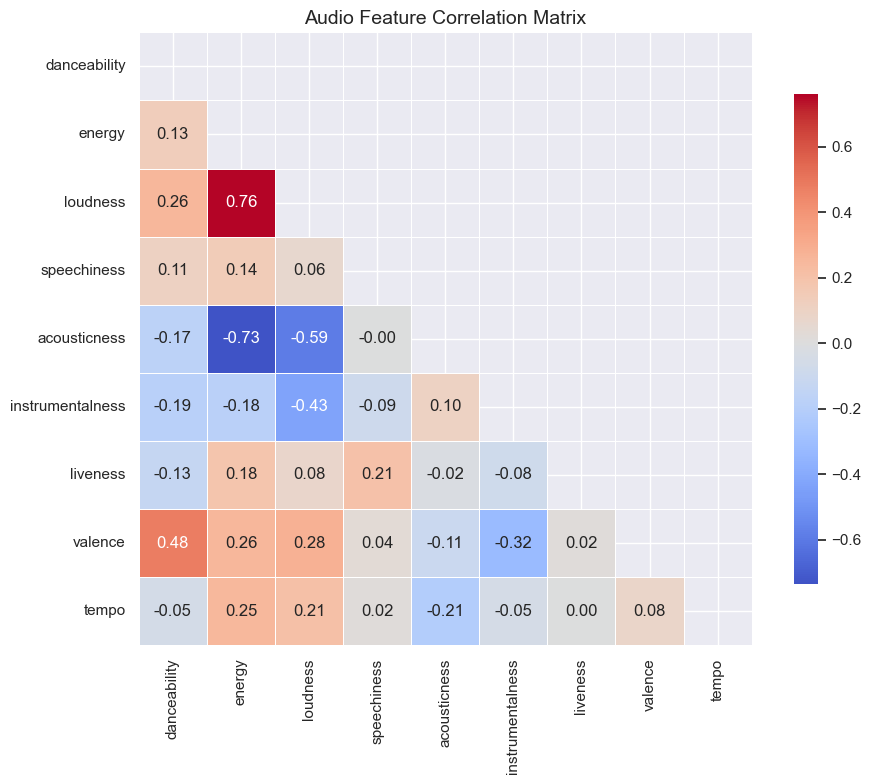

In [59]:
corr = sp_tracks[available_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, square=True,
    linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Audio Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS / 'correlation_heatmap.png', dpi=150)
plt.show()

Notes:

energy & loudness are highly redundant — we need to drop one to avoid double-weighting

acousticness already captures the opposite of energy, so it adds useful contrast

Most features are weakly correlated → they each contribute unique information to the similarity vector, which is good for cosine similarity


## 8. Genre Distribution


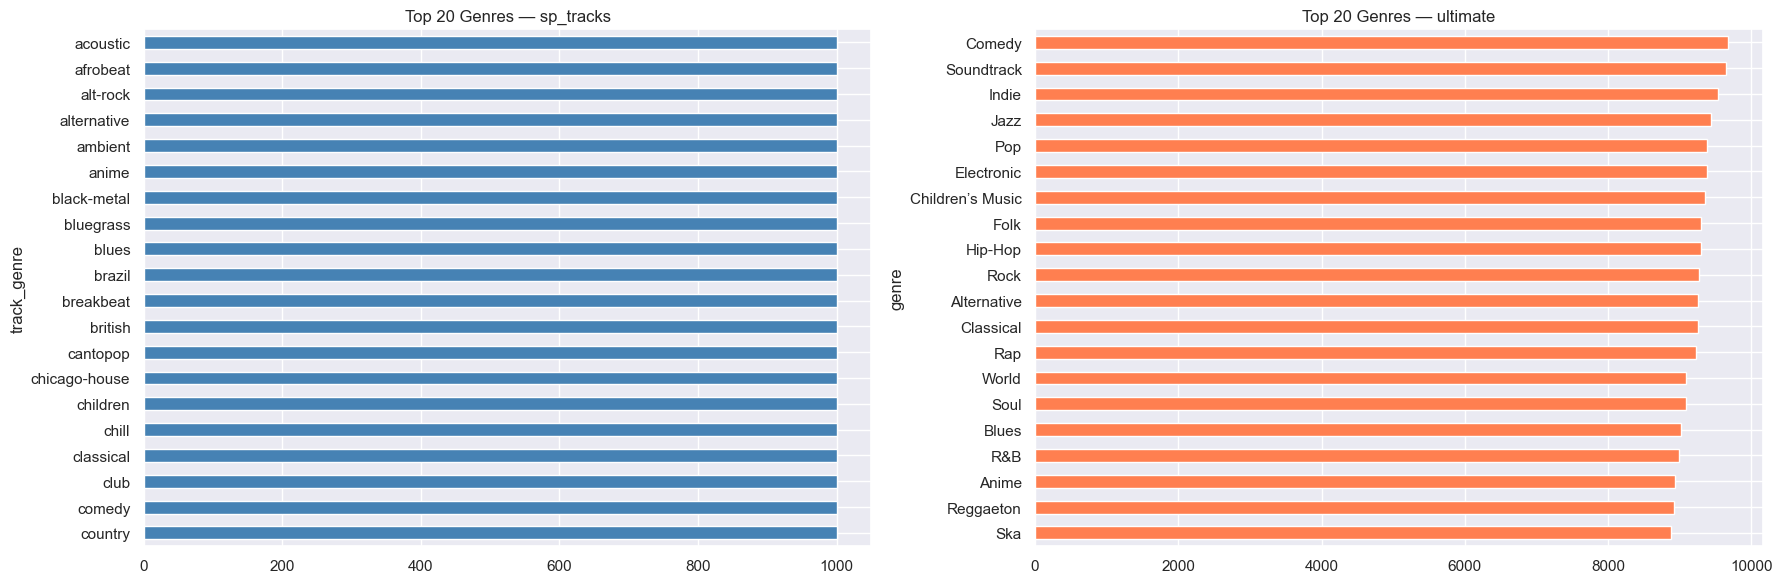

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if 'track_genre' in sp_tracks.columns:
    top_genres = sp_tracks['track_genre'].value_counts().head(20)
    top_genres.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_title('Top 20 Genres — sp_tracks')
    axes[0].invert_yaxis()

if 'genre' in ultimate.columns:
    top_genres2 = ultimate['genre'].value_counts().head(20)
    top_genres2.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_title('Top 20 Genres — ultimate')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(PLOTS / 'genre_distribution.png', dpi=150)
plt.show()

## 9. Popularity Distribution


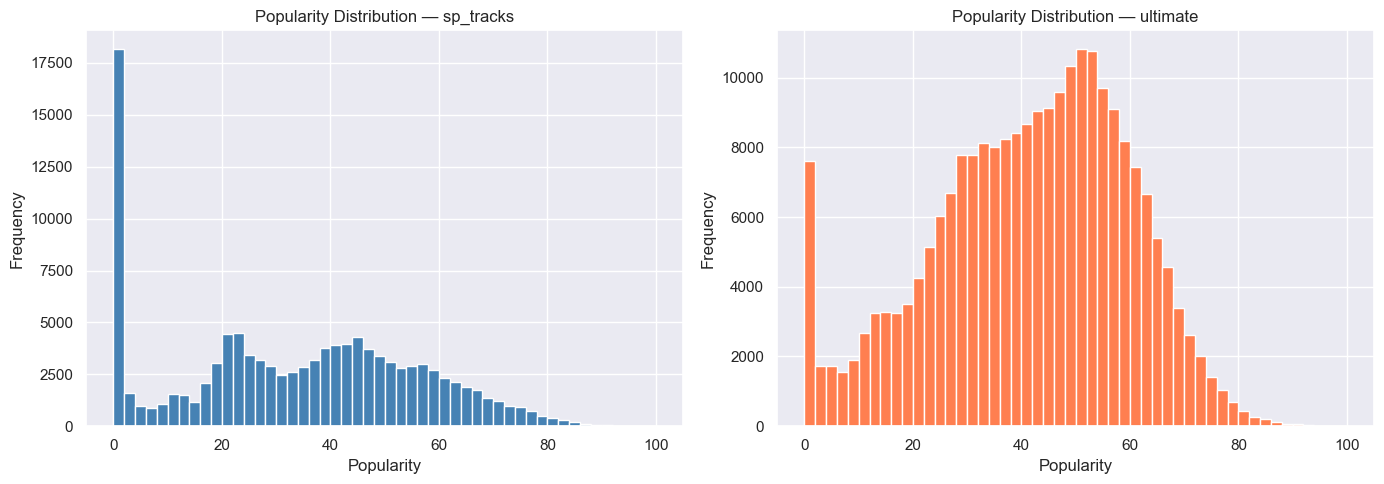

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sp_tracks['popularity'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Popularity Distribution — sp_tracks')
axes[0].set_xlabel('Popularity')

ultimate['popularity'].plot(kind='hist', bins=50, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Popularity Distribution — ultimate')
axes[1].set_xlabel('Popularity')

plt.tight_layout()
plt.savefig(PLOTS / 'popularity_distribution.png', dpi=150)
plt.show()

## 10. Audio Features by Genre (Top 10)


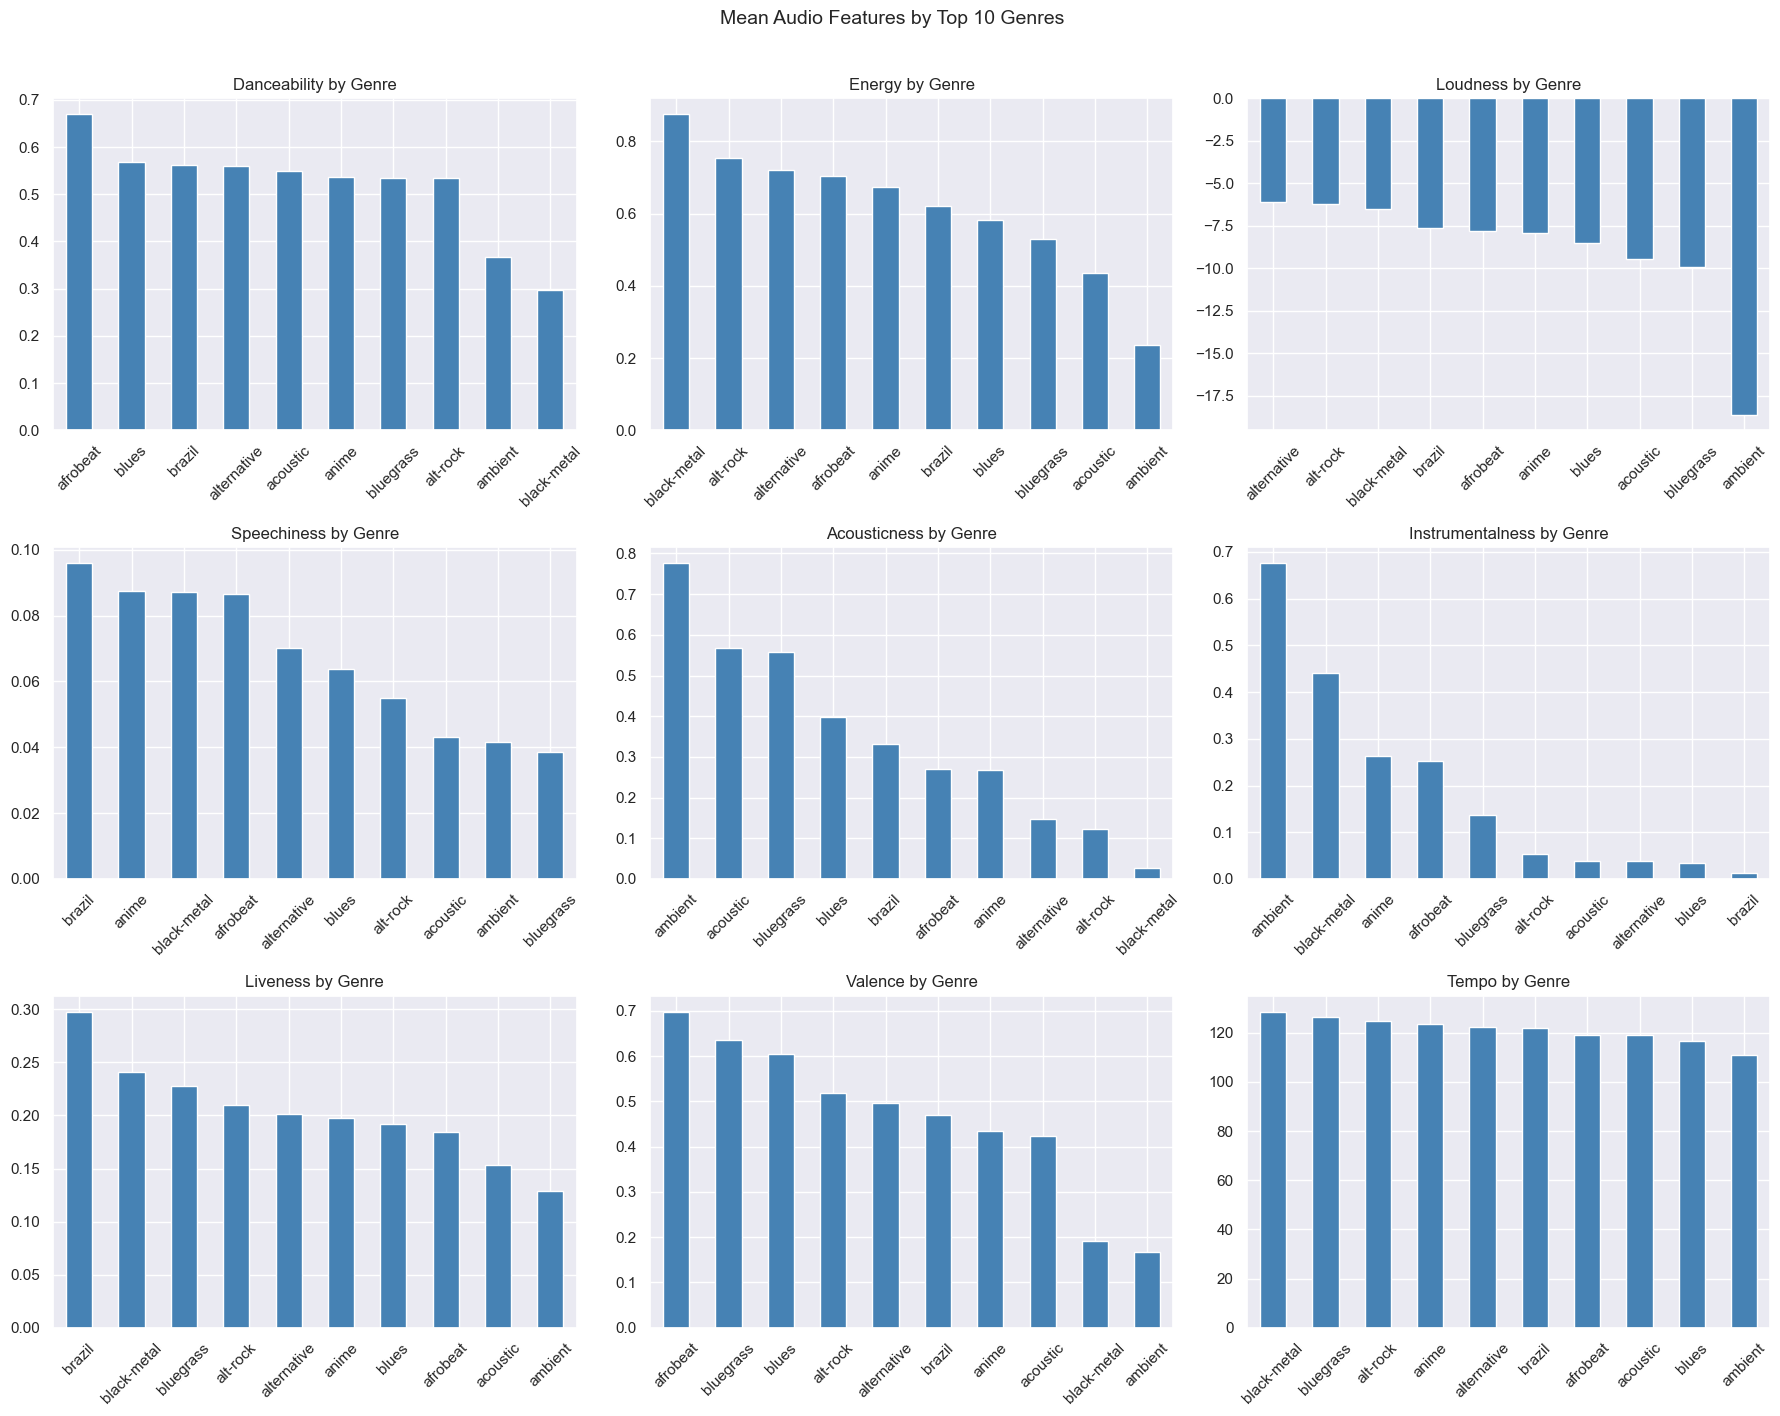

In [62]:
top10_genres = sp_tracks['track_genre'].value_counts().head(10).index
df_top = sp_tracks[sp_tracks['track_genre'].isin(top10_genres)]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for ax, feature in zip(axes, available_features):
    genre_means = df_top.groupby('track_genre')[feature].mean().sort_values(ascending=False)
    genre_means.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'{feature.capitalize()} by Genre')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Mean Audio Features by Top 10 Genres', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS / 'features_by_genre.png', dpi=150)
plt.show()

## 11. Energy vs Valence (Mood Scatter)


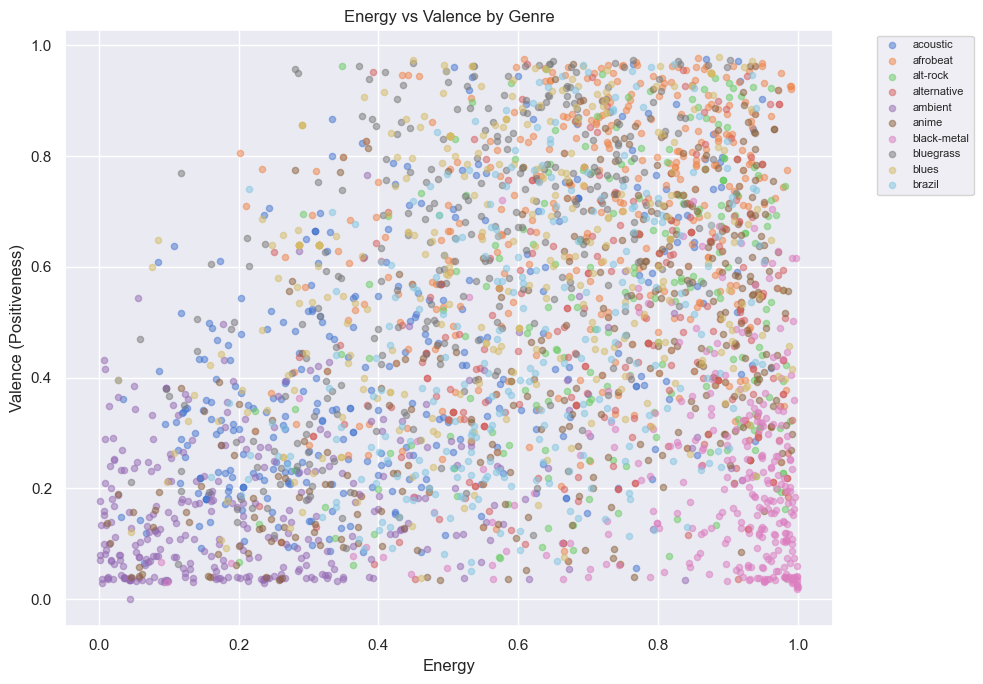

In [63]:
sample = sp_tracks[sp_tracks['track_genre'].isin(top10_genres)].sample(3000, random_state=42)

plt.figure(figsize=(10, 7))
for genre in top10_genres:
    subset = sample[sample['track_genre'] == genre]
    plt.scatter(subset['energy'], subset['valence'], label=genre, alpha=0.5, s=20)

plt.xlabel('Energy')
plt.ylabel('Valence (Positiveness)')
plt.title('Energy vs Valence by Genre')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS / 'energy_vs_valence.png', dpi=150)
plt.show()

## 12. Dataset Overlap — Common Columns


In [64]:
from collections import Counter

print('Columns available in ALL datasets:')
all_cols = [set(df.columns) for df in datasets.values()]
common = set.intersection(*all_cols)
print(sorted(common))

print('\nColumns present in >= 4 datasets:')
col_count = Counter(col for df in datasets.values() for col in df.columns)
print(sorted([col for col, cnt in col_count.items() if cnt >= 4]))

Columns available in ALL datasets:
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']

Columns present in >= 4 datasets:
['acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'popularity', 'speechiness', 'tempo', 'time_signature', 'track_id', 'track_name', 'valence']


## 13. EDA Summary & Observations

| Observation                     | Detail                                                                                                |
| ------------------------------- | ----------------------------------------------------------------------------------------------------- |
| Best dataset for recommendation | `sp_tracks` — has genre + all audio features + popularity                                             |
| Richest metadata                | `spotify_2023` — has artist, album, release date, genres                                              |
| Common core features            | danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo |
| Duplicates to handle            | Check per dataset in preprocessing                                                                    |
| Missing values                  | Mostly in metadata columns, not in audio features                                                     |
| Recommendation strategy         | Use audio features as vectors for cosine similarity                                                   |
